<a href="https://colab.research.google.com/github/alexadandridge/AdvancedMachineLearning/blob/master/AlexaDandridgeCopy_of_Inclass_05_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# In Class May 19

In [109]:
# importing libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Importing the data

In [110]:
# importing mnist data from keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


### Visualizing the data

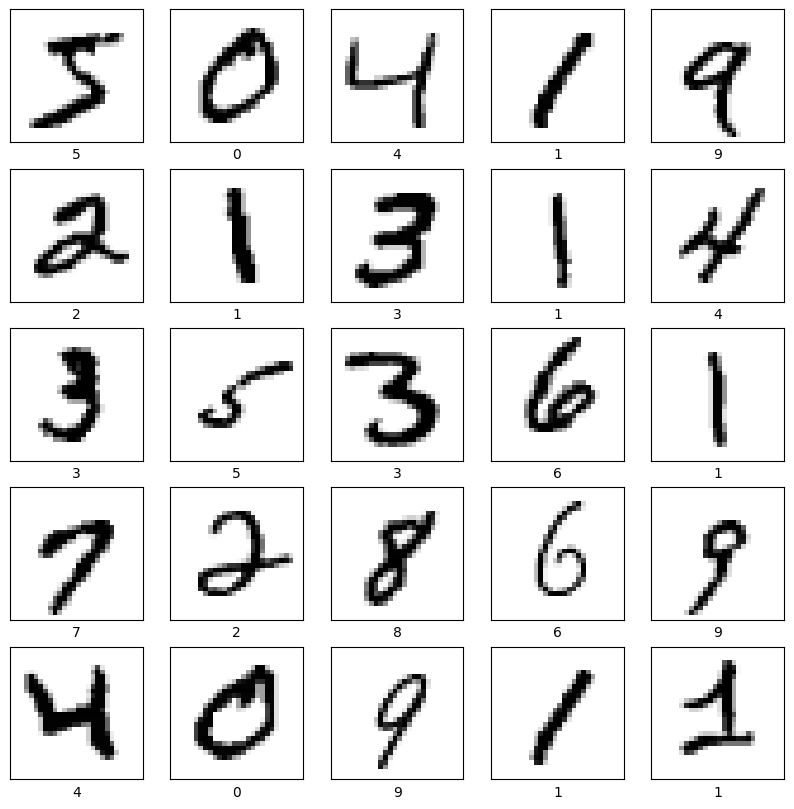

In [111]:
# visualize some of the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

### Preprocessing data for MLP

In [112]:

# Normalize pixel values to 0–1
X_train_norm = X_train / 255.0   # scale pixel values from 0–255 → 0–1
X_test_norm = X_test / 255.0     # apply same scaling to test data

# Flatten images for the MLP
X_train_flat = X_train_norm.reshape(X_train.shape[0], -1)  # # reshape from (60000, 28, 28) → (60000, 784)
X_test_flat = X_test_norm.reshape(X_test.shape[0], -1)     # same transformation for test images

print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


### Building the MLP model

In [113]:
# Define the MLP baseline model
mlp_model = keras.Sequential([
    layers.Input(shape=(784,)),                 # input is a flattened image (784 pixels)
    layers.Dense(128, activation="relu"),       # hidden layer with 128 neurons (learns patterns)
    layers.Dense(64, activation="relu"),        # second hidden layer for more complex patterns
    layers.Dense(10, activation="softmax"),     # output layer (10 classes for digits 0–9)
])

# Compile the MLP model
mlp_model.compile(
    optimizer="adam",                           # optimization algorithm for training
    loss="sparse_categorical_crossentropy",     # loss for multi-class classification with integer labels
    metrics=["accuracy"]                        # track accuracy during training
)

# summary of the MLP model architecture
mlp_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
# train the MLP model
history_mlp = mlp_model.fit(
    X_train_flat,                               # flattened training images
    y_train,                                    # labels (0–9)
    epochs=5,                                   # number of training passes through data
    batch_size=128,                             # number of samples per training step
    validation_split=0.1                        # use 10% of training data for validation
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_model.evaluate(X_test_flat, y_test, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9011 - loss: 0.3474 - val_accuracy: 0.9600 - val_loss: 0.1489
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9591 - loss: 0.1403 - val_accuracy: 0.9725 - val_loss: 0.1005
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9714 - loss: 0.0973 - val_accuracy: 0.9725 - val_loss: 0.0895
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9780 - loss: 0.0732 - val_accuracy: 0.9747 - val_loss: 0.0871
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9829 - loss: 0.0571 - val_accuracy: 0.9762 - val_loss: 0.0864
313/313 - 1s - 3ms/step - accuracy: 0.9735 - loss: 0.0877
MLP Test accuracy: 0.9735


We do not always need a CNN for every neural network.

### Preparing data for CNN

In [115]:
X_train_cnn = X_train_norm[..., np.newaxis]  # add channel dimension → (60000, 28, 28, 1)
X_test_cnn = X_test_norm[..., np.newaxis]    # same for test data

print("CNN input shape:", X_train_cnn.shape)  # confirm new shape for CNN

CNN input shape: (60000, 28, 28, 1)


### Building the CNN model

In [116]:
# define the model

cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # apply 32 filters to detect local patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                   # reduce spatial size (summarize important features)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for digits 0–9
])

In [117]:
# compile the model
cnn_model.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history = cnn_model.fit(
    X_train_cnn,                                  # image data with spatial structure
    y_train,                                      # labels (correct digits)
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9463 - loss: 0.1794 - val_accuracy: 0.9810 - val_loss: 0.0720
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9816 - loss: 0.0612 - val_accuracy: 0.9820 - val_loss: 0.0575
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9871 - loss: 0.0416 - val_accuracy: 0.9853 - val_loss: 0.0559
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.9902 - loss: 0.0303 - val_accuracy: 0.9892 - val_loss: 0.0486
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9928 - loss: 0.0220 - val_accuracy: 0.9887 - val_loss: 0.0565


### Evaluating the CNN model

In [118]:
# Evaluate the CNN on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)  # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9854 - loss: 0.0455
CNN Test Accuracy: 0.9854000210762024


### MLP vs CNN model

In [119]:
# Compare the CNN's performance to the MLP baseline
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")
print(f"CNN Test accuracy: {cnn_acc:.4f}")


MLP Test accuracy: 0.9735
CNN Test accuracy: 0.9854


### Visualizing model training

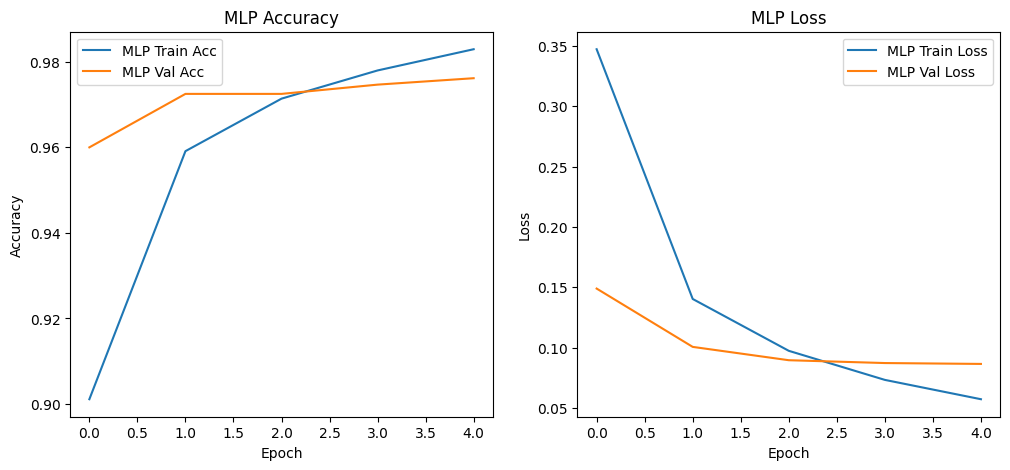

In [120]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['accuracy'], label='MLP Train Acc')
plt.plot(history_mlp.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['loss'], label='MLP Train Loss')
plt.plot(history_mlp.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


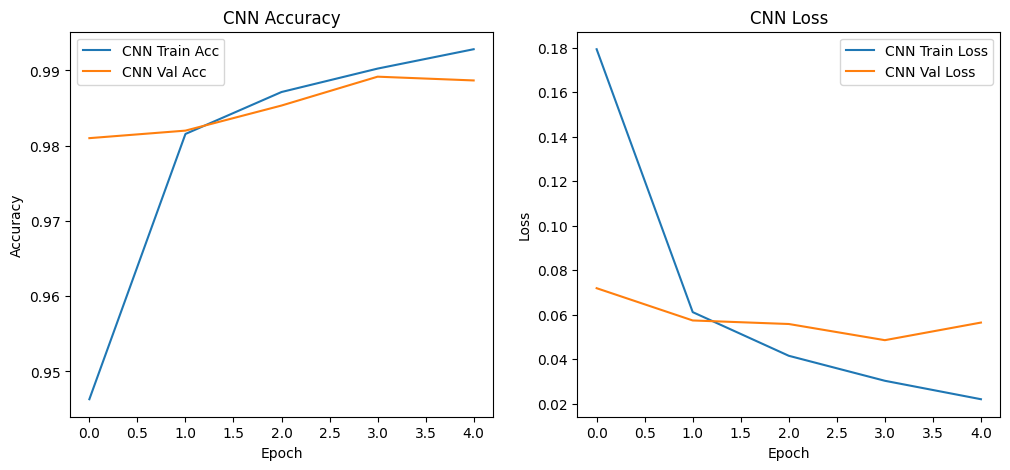

In [121]:
# plot training history for CNN (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


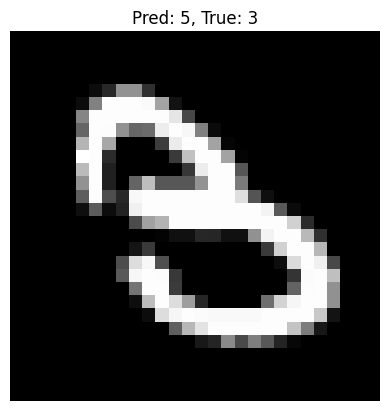

In [122]:
# Get predictions
cnn_predictions = cnn_model.predict(X_test_cnn)

# Find a misclassified example
for i in range(len(X_test)):
    pred = np.argmax(cnn_predictions[i])  # predicted class

    if pred != y_test[i]:                 # compare to true label
        plt.imshow(X_test[i], cmap="gray")
        plt.title(f"Pred: {pred}, True: {y_test[i]}")
        plt.axis("off")
        break

### How well do the models perform if we rotate the images?

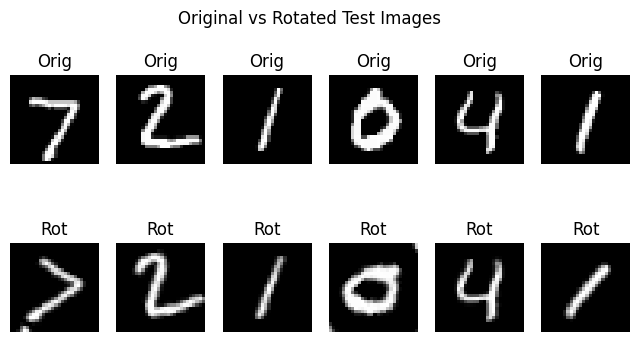

In [123]:
# Visualize rotated test images (to see what changed)

rotation_layer_eval = tf.keras.layers.RandomRotation(0.15)

X_test_rot_eval_cnn = rotation_layer_eval(X_test_cnn, training=True)

plt.figure(figsize=(8, 4))

for i in range(6):
    # Original
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Orig")
    plt.axis('off')

    # Rotated
    plt.subplot(2, 6, i + 7)
    plt.imshow(X_test_rot_eval_cnn[i].numpy().squeeze(), cmap='gray')
    plt.title("Rot")
    plt.axis('off')

plt.suptitle("Original vs Rotated Test Images")
plt.show()

In [124]:
# Flatten rotated images for MLP
X_test_rot_eval_flat = X_test_rot_eval_cnn.numpy().reshape(X_test.shape[0], -1)

# Evaluate original models on rotated data
mlp_rot_eval_loss, mlp_rot_eval_acc = mlp_model.evaluate(X_test_rot_eval_flat, y_test)
cnn_rot_eval_loss, cnn_rot_eval_acc = cnn_model.evaluate(X_test_rot_eval_cnn, y_test)

print("MLP accuracy (original test):", test_acc_mlp)
print("MLP accuracy (rotated test):", mlp_rot_eval_acc)

print("CNN accuracy (original test):", cnn_acc)
print("CNN accuracy (rotated test):", cnn_rot_eval_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7162 - loss: 1.3537
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7696 - loss: 1.1814
MLP accuracy (original test): 0.9735000133514404
MLP accuracy (rotated test): 0.7161999940872192
CNN accuracy (original test): 0.9854000210762024
CNN accuracy (rotated test): 0.769599974155426


The CNN struggles, but it still better than just the MLP when the values are rotated.

### New models trained with data augmentation (random rotations)

In [125]:
# Create rotated datasets for retraining models
rotation_layer_train = tf.keras.layers.RandomRotation(0.15)

X_train_rot_train_cnn = rotation_layer_train(X_train_cnn, training=True)  # rotated training images for CNN
X_test_rot_train_cnn = rotation_layer_train(X_test_cnn, training=True)    # rotated test images for CNN

# Flatten rotated datasets for MLP
X_train_rot_train_flat = X_train_rot_train_cnn.numpy().reshape(X_train.shape[0], -1)
X_test_rot_train_flat = X_test_rot_train_cnn.numpy().reshape(X_test.shape[0], -1)

### Use the code cell below to build, train and evaluate an MLP model using the rotated data (X_train_rot_train_flat and X_test_rot_train_flat)

In [126]:
# your code here

In [127]:
print(X_train_rot_train_flat.shape)
print(X_test_rot_train_flat.shape)

(60000, 784)
(10000, 784)


In [128]:
# Define MLP model for rotated data
mlp_rot_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

# Compile model
mlp_rot_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# summary of the MLP model architecture
mlp_rot_model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [129]:
# Train on rotated training data
history_mlp_rot = mlp_rot_model.fit(
    X_train_rot_train_flat,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

# Evaluate on rotated test data
test_loss_mlp_rot, test_acc_mlp_rot = mlp_rot_model.evaluate(
    X_test_rot_train_flat,
    y_test,
    verbose=2
)

print(f"Rotated MLP Test accuracy: {test_acc_mlp_rot:.4f}")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8259 - loss: 0.5850 - val_accuracy: 0.9112 - val_loss: 0.2924
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9161 - loss: 0.2836 - val_accuracy: 0.9432 - val_loss: 0.1987
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9378 - loss: 0.2087 - val_accuracy: 0.9502 - val_loss: 0.1745
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9494 - loss: 0.1685 - val_accuracy: 0.9495 - val_loss: 0.1767
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9579 - loss: 0.1403 - val_accuracy: 0.9510 - val_loss: 0.1561
313/313 - 1s - 2ms/step - accuracy: 0.9461 - loss: 0.1804
Rotated MLP Test accuracy: 0.9461


### Use the code cell below to build, train and evaluate a CNN model using the rotated data (X_train_rot_train_cnn and X_test_rot_train_cnn)

In [ ]:
print("CNN input shape:", X_train_rot_train_cnn.shape)

In [130]:

# Define CNN model for rotated data
cnn_rot_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

In [131]:
# Compile the model
cnn_rot_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train on rotated training data
cnn_history_rot = cnn_rot_model.fit(
    X_train_rot_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.1
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.8892 - loss: 0.3608 - val_accuracy: 0.9593 - val_loss: 0.1338
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9571 - loss: 0.1427 - val_accuracy: 0.9687 - val_loss: 0.1092
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9691 - loss: 0.0997 - val_accuracy: 0.9723 - val_loss: 0.0947
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9756 - loss: 0.0763 - val_accuracy: 0.9735 - val_loss: 0.0896
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9810 - loss: 0.0582 - val_accuracy: 0.9762 - val_loss: 0.0851


In [132]:
# Evaluate on rotated test data
cnn_loss_rot, cnn_acc_rot = cnn_rot_model.evaluate(
    X_test_rot_train_cnn,
    y_test
)

print(f"Rotated CNN Test Accuracy: {cnn_acc_rot:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9700 - loss: 0.0994
Rotated CNN Test Accuracy: 0.9700


### Using the markdown cell below evaluate the performance of the MLP vs the CNN. Use graphs and metrics to support your evaluation.

In [133]:
# Compare final test accuracies
print(f"Rotated MLP Test Accuracy: {test_acc_mlp_rot:.4f}")
print(f"Rotated CNN Test Accuracy: {cnn_acc_rot:.4f}")

Rotated MLP Test Accuracy: 0.9461
Rotated CNN Test Accuracy: 0.9700


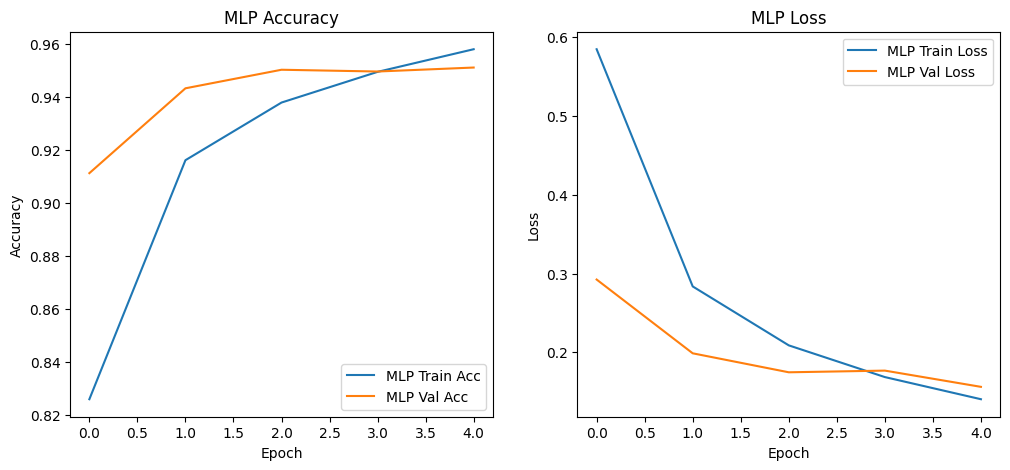

In [134]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_mlp_rot.history['accuracy'], label='MLP Train Acc')
plt.plot(history_mlp_rot.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mlp_rot.history['loss'], label='MLP Train Loss')
plt.plot(history_mlp_rot.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

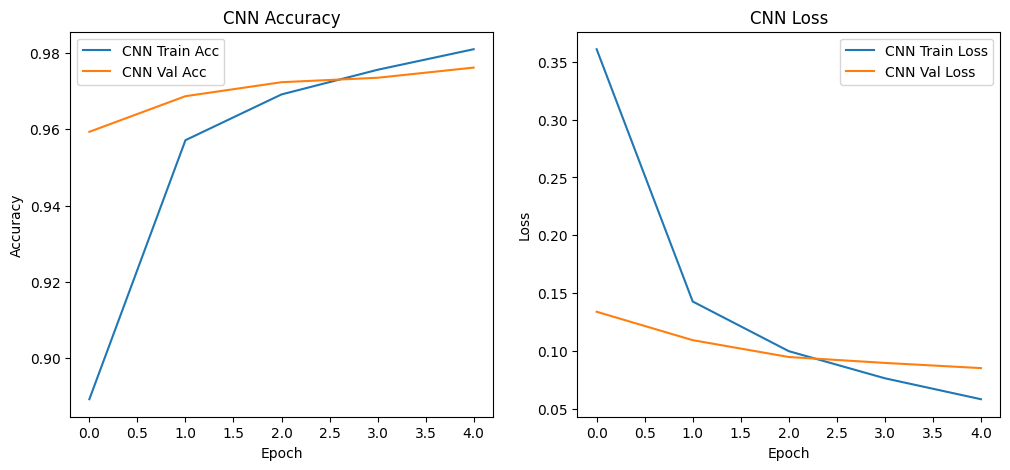

In [135]:
# Plot training history for CNN (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history_rot.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history_rot.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history_rot.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history_rot.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

The models perform slightly worse on rotated images than on normal images. Before rotation, the MLP model scored a 97% accuracy and CNN had obtained a 98% accuracy. After rotation, the MLP model scored a 94% accuracy and the CNN had a 97% accuracy. In both times, the CNN performed better than the MLP.


The graphs above show that for MLP, training and validation accuracy increases as epoch value increases. MLP validation accuracy is consistently higher than MLP training accuracy. MLP train loss and MLP validation loss both decrease as epoch value increases. MLP train loss is consistently higher than MLP validation loss until the two lines merge around 4 epochs.

CNN train and validation accuracy both typically increase as epoch value increases. CNN validation accuracy appears more stable and is higher than CNN train accuracy until their intersection at about 2.5 epochs, and then CNN train accuracy surpasses CNN validation accuracy. CNN train loss is higher than CNN validation loss until their intersection at around 2.5 epochs where the CNN validation loss becomes higher than the CNN train loss.

The training curves also show that both models improved over time without major overfitting, since training and validation performance remained relatively close. However, the CNN converged faster and reached better overall performance.